In [1]:
# Charger heartdisease/data_with_nan na_values="."
# Compter les nan pour tous le dataframe
# Il y a 3 colonnes avec un ratio > 80% de nan : drop ces colonnes ("en dur")
# Pour les colonnes qui ont + 10 nan remplacer avec un apply la valeur par un moyenne de la colonne (np.mean, np.nanmean, df.mean)
# Bonus : remplacer les nan par moyenne + (np.random.rand() - 0.5) * 2 * std
# Pour les autres nan effectuer un dropna => virer les lignes
# Sauvegarder le df dans dataclean.csv

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("data/heartdisease/data_with_nan.csv", na_values=".")
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,0
2,29,1,2,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0
5,32,0,2,105.0,198.0,0.0,0.0,165.0,0.0,0.0,NaN,NaN,NaN,0
6,32,1,2,110.0,225.0,0.0,0.0,184.0,0.0,0.0,NaN,NaN,NaN,0
7,32,1,2,125.0,254.0,0.0,0.0,155.0,0.0,0.0,NaN,NaN,NaN,0
8,33,1,3,120.0,298.0,0.0,0.0,185.0,0.0,0.0,NaN,NaN,NaN,0
9,34,0,2,130.0,161.0,0.0,0.0,190.0,0.0,0.0,NaN,NaN,NaN,0


In [4]:
df.isnull().sum() / df.shape[0]

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.003401
chol        0.078231
fbs         0.027211
restecg     0.003401
thalach     0.003401
exang       0.003401
oldpeak     0.000000
slope       0.646259
ca          0.989796
thal        0.904762
num         0.000000
dtype: float64

In [5]:
df = df.drop(["slope", "ca", "thal"], axis=1)
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,0
2,29,1,2,140.0,NaN,0.0,0.0,170.0,0.0,0.0,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,0
5,32,0,2,105.0,198.0,0.0,0.0,165.0,0.0,0.0,0
6,32,1,2,110.0,225.0,0.0,0.0,184.0,0.0,0.0,0
7,32,1,2,125.0,254.0,0.0,0.0,155.0,0.0,0.0,0
8,33,1,3,120.0,298.0,0.0,0.0,185.0,0.0,0.0,0
9,34,0,2,130.0,161.0,0.0,0.0,190.0,0.0,0.0,0


In [6]:
chol_mean = df["chol"].mean()
chol_std = np.nanstd(df["chol"])
chol_mean, chol_std

(np.float64(250.84870848708488), np.float64(67.53276632755606))

<Axes: >

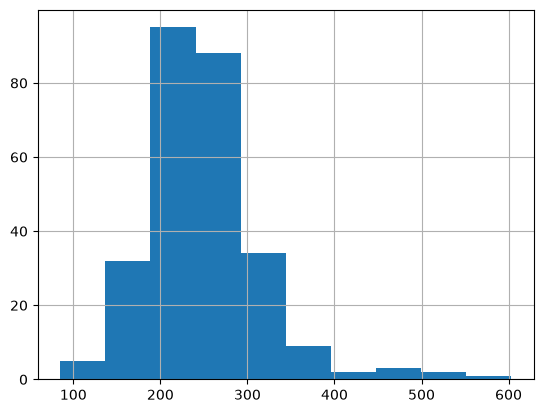

In [7]:
df["chol"].hist(bins=10)

In [8]:
# df["chol"] = df["chol"].fillna(chol_mean)
# df["chol"].isnull().sum()

In [9]:
nb_chol_na = df["chol"].isnull().sum()
nb_chol_na

np.int64(23)

In [10]:
df["chol"] = df["chol"].apply(lambda c: chol_mean + chol_std * (np.random.rand() - 0.5) * 2 if pd.isna(c) else c)

In [11]:
# random_values = chol_mean + chol_std * np.random.rand(nb_chol_na)
# df.loc[df['chol'].isna()]['chol'] = random_values

In [12]:
df = df.dropna()
df.shape

(284, 11)

In [13]:
df.to_csv("data/heartdisease/dataclean.csv", index=False)

In [20]:
df.mean(axis=0)["chol"]
df["chol"].mean()

np.float64(248.77763964306473)

In [24]:
df["num"] = df["num"].astype("category")
df.dtypes

age            int64
sex            int64
cp             int64
trestbps     float64
chol         float64
fbs          float64
restecg      float64
thalach      float64
exang        float64
oldpeak      float64
num         category
dtype: object

In [34]:
for index, item in df.iterrows():
    print(index, item["chol"])

0 132.0
1 243.0
2 201.49192897564654
3 237.0
4 219.0
5 198.0
6 225.0
7 254.0
8 298.0
9 161.0
10 214.0
11 220.0
12 160.0
13 167.0
14 308.0
15 264.0
16 166.0
17 340.0
18 209.0
19 160.0
20 260.0
21 211.0
22 173.0
23 283.0
24 194.0
25 223.0
26 315.0
28 297.0
29 292.0
30 182.0
31 288.660583016909
32 200.0
33 204.0
34 308.1902691248067
35 241.0
36 339.0
37 147.0
38 273.0
39 307.0
40 275.0
41 289.0
42 215.0
43 281.0
44 294.91506720855745
45 250.0
46 184.0
47 245.0
48 291.0
49 295.0
50 269.0
51 250.0
52 211.0
53 196.0
54 198.0
55 268.0
56 228.0
57 147.0
58 358.0
59 223.0
60 201.0
61 215.0
62 249.0
63 266.0
64 186.0
65 211.65788184490626
66 207.0
67 218.0
68 184.0
69 215.0
70 412.0
71 237.0
72 219.24782366980915
73 297.0
74 224.0
75 189.32117827261132
76 225.0
77 224.0
78 238.0
79 275.0
80 230.0
82 238.0
83 240.0
84 280.0
85 257.0
86 313.7869571697132
87 249.0
88 263.0
89 276.0
91 193.20423523234754
92 284.0
93 195.0
94 163.0
95 254.0
96 227.0
97 189.79505793642608
98 245.0
99 238.0
100 211.0
1